# Phase 1: Advanced Regression Modeling

In this notebook, you will:
1. Load and explore the California Housing dataset
2. Preprocess features and engineer new ones
3. Build multiple regression models (Linear, Ridge, Lasso, ElasticNet, Polynomial)
4. Build tree-based models (Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM)
5. Evaluate and compare all models
6. Check for multicollinearity (VIF) and heteroskedasticity
7. Perform cross-validation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import your modules
import sys
sys.path.insert(0, '..')
from src.data_loader import load_housing_data, preprocess_features, split_data, create_feature_engineering
from src.regression import *

## 1. Data Loading & Exploration

In [2]:
# Load the dataset
df = load_housing_data()
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Basic statistics
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


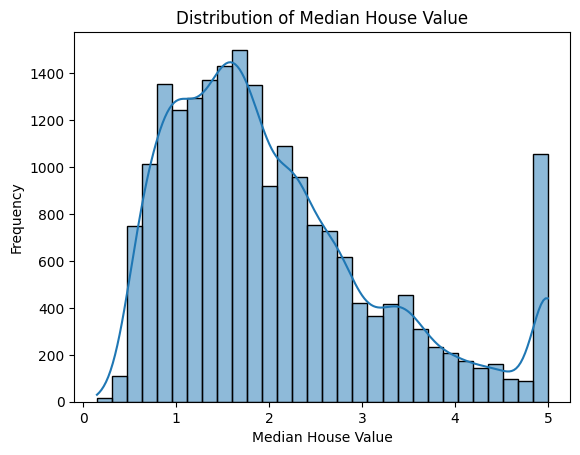

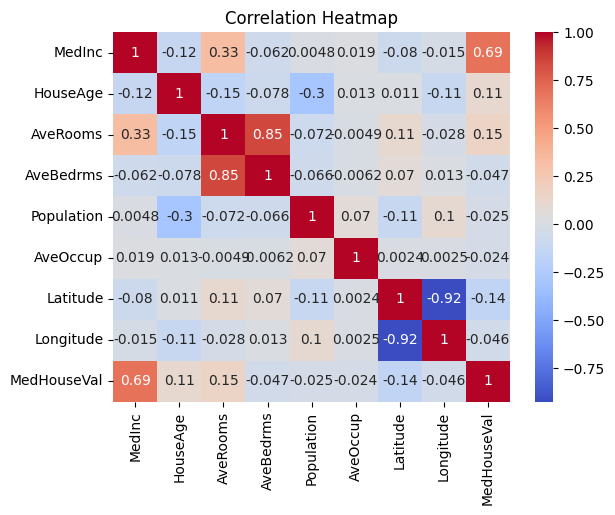

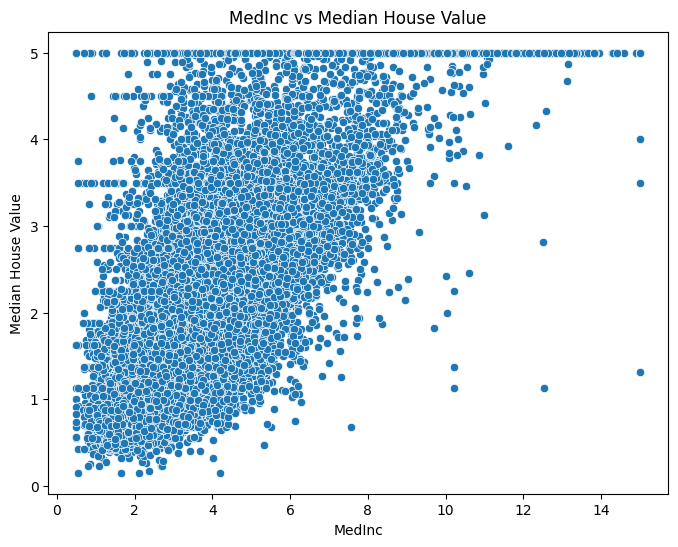

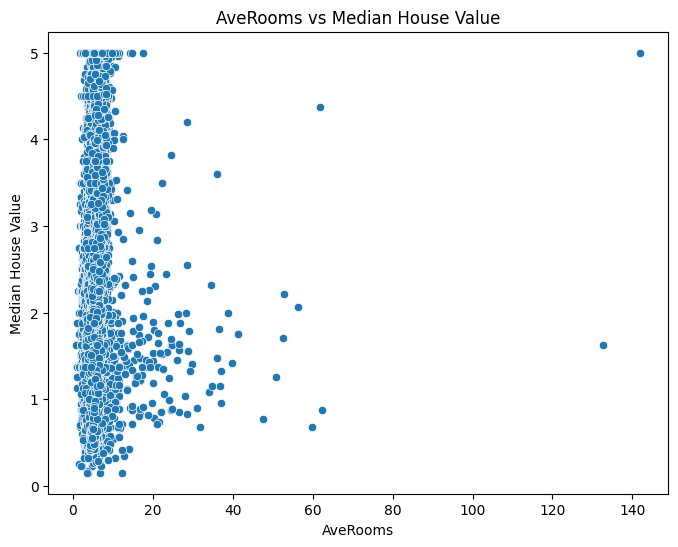

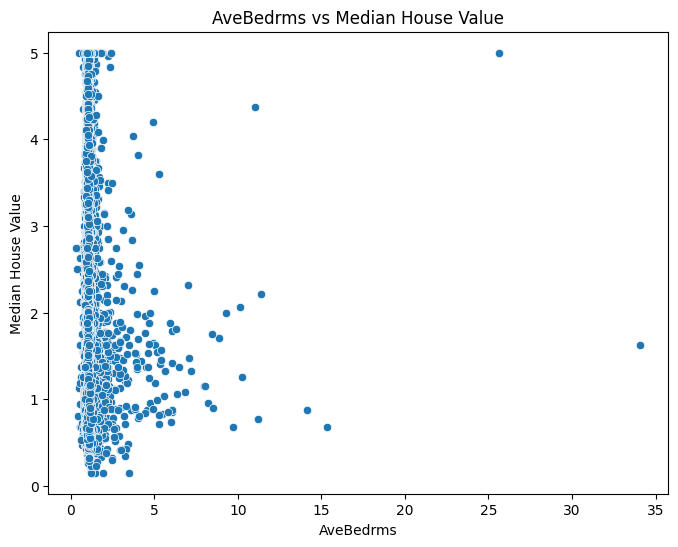

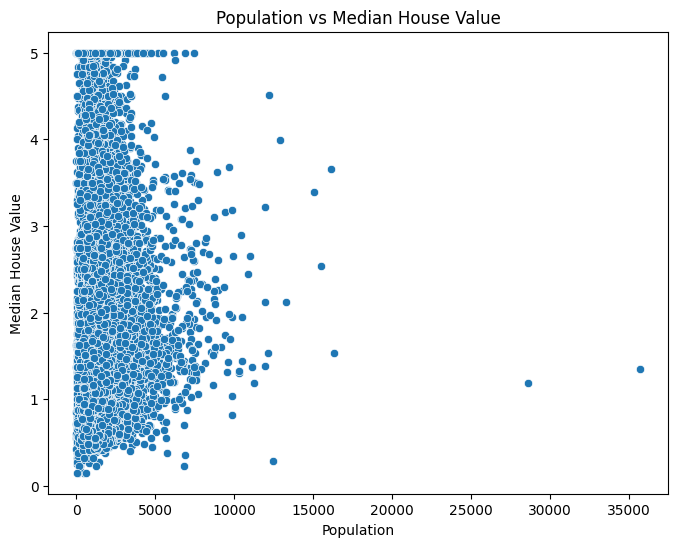

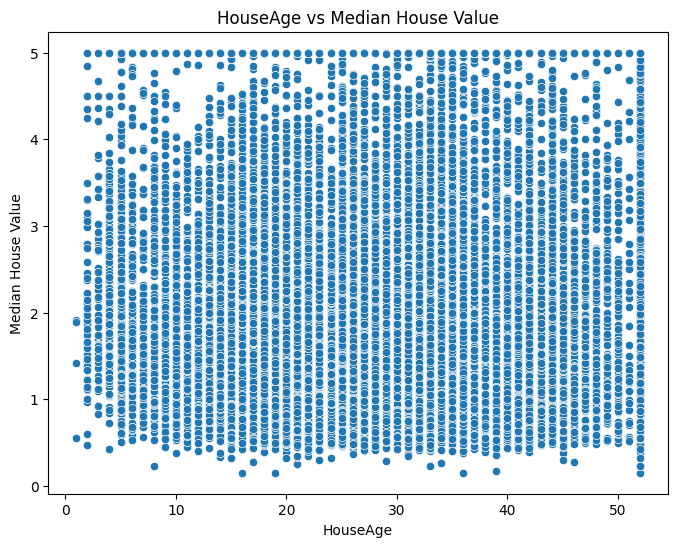

In [4]:
# TODO: Create visualizations
# - Distribution of target variable (MedHouseVal)
# - Correlation heatmap
# - Scatter plots of key features vs target
# Distribution of target variable
plt.figsize=(10,6)
sns.histplot(df['MedHouseVal'], bins=30,kde=True)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

# Correlation heatmap
plt.figsixe=(12,10)
corr = df.corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Scatter plots of key features vs target
keyFeatures = ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'HouseAge']
for feature in keyFeatures:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=df[feature], y=df['MedHouseVal'])
    plt.title(f'{feature} vs Median House Value')
    plt.xlabel(feature)
    plt.ylabel('Median House Value')
    plt.show()


## 2. Feature Engineering & Preprocessing

In [5]:
# Engineer new features
df_eng = create_feature_engineering(df)
print(f"Original columns: {df.shape[1]}")
print(f"After engineering: {df_eng.shape[1]}")
print(f"New columns: {set(df_eng.columns) - set(df.columns)}")

Original columns: 9
After engineering: 12
New columns: {'bedrooms_ratio', 'population_density', 'rooms_per_household'}


In [6]:
# Preprocess and split
X_scaled, y, feature_names, scaler = preprocess_features(df_eng)
X_train, X_test, y_train, y_test = split_data(X_scaled, y)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (16512, 8), Test size: (4128, 8)


## 3. Linear Models

In [7]:
# TODO: Build and evaluate each linear model
# - Linear Regression
# - Ridge Regression (try multiple alphas)
# - Lasso Regression (try multiple alphas)
# - ElasticNet (try multiple alpha and l1_ratio combinations)
# - Polynomial Regression (try degree 2 and 3)

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train,y_train)
lr_preds = lr_model.predict(X_test)
lr_mse = mean_squared_error(y_test, lr_preds)
print(f"Linear Regression MSE: {lr_mse:.4f}")

#ridge gregression
alphas = [0.1, 1, 10, 100]
for a in alphas:
    ridge_model = Ridge(alpha=a)
    ridge_model.fit(X_train, y_train)
    ridge_preds = ridge_model.predict(X_test)
    ridge_mse = mean_squared_error(y_test, ridge_preds)
    print(f"Ridge Regression (alpha={a}) MSE: {ridge_mse:.4f}")

#Lasso Regression
alphas = [0.1, 1, 10, 100]
for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train, y_train)
    lasso_preds = lasso_model.predict(X_test)
    lasso_mse = mean_squared_error(y_test, lasso_preds)
    print(f"Lasso Regression (alpha={a}) MSE: {lasso_mse:.4f}")

#ElasticNet
alphas = [0.1, 1, 10]
l1_ratios = [0.2, 0.5, 0.8]
for a in alphas:
    for l1 in l1_ratios:
        enet_model = ElasticNet(alpha=a, l1_ratio=l1)
        enet_model.fit(X_train, y_train)
        enet_preds = enet_model.predict(X_test)
        enet_mse = mean_squared_error(y_test, enet_preds)
        print(f"ElasticNet (alpha={a}, l1_ratio={l1}) MSE: {enet_mse:.4f}")

# Polynomial Regression
from sklearn.preprocessing import PolynomialFeatures
degrees = [2, 3]
for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)
    poly_preds = poly_model.predict(X_test_poly)
    poly_mse = mean_squared_error(y_test, poly_preds)
    print(f"Polynomial Regression (degree={d}) MSE: {poly_mse:.4f}")


Linear Regression MSE: 0.5559
Ridge Regression (alpha=0.1) MSE: 0.5559
Ridge Regression (alpha=1) MSE: 0.5559
Ridge Regression (alpha=10) MSE: 0.5555
Ridge Regression (alpha=100) MSE: 0.5530
Lasso Regression (alpha=0.1) MSE: 0.6796
Lasso Regression (alpha=1) MSE: 1.3107
Lasso Regression (alpha=10) MSE: 1.3107
Lasso Regression (alpha=100) MSE: 1.3107
ElasticNet (alpha=0.1, l1_ratio=0.2) MSE: 0.6012
ElasticNet (alpha=0.1, l1_ratio=0.5) MSE: 0.6358
ElasticNet (alpha=0.1, l1_ratio=0.8) MSE: 0.6718
ElasticNet (alpha=1, l1_ratio=0.2) MSE: 0.9080
ElasticNet (alpha=1, l1_ratio=0.5) MSE: 1.0430
ElasticNet (alpha=1, l1_ratio=0.8) MSE: 1.3107
ElasticNet (alpha=10, l1_ratio=0.2) MSE: 1.3107
ElasticNet (alpha=10, l1_ratio=0.5) MSE: 1.3107
ElasticNet (alpha=10, l1_ratio=0.8) MSE: 1.3107
Polynomial Regression (degree=2) MSE: 0.4643
Polynomial Regression (degree=3) MSE: 25.4071


## 4. Tree-Based Models

In [11]:

# TODO: Build and evaluate tree-based models
# - Decision Tree
# - Random Forest
# - Gradient Boosting
# - XGBoost
# - LightGBM

#Decision Tree
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
dt_mse = mean_squared_error(y_test, dt_preds)
print(f"Decision Tree MSE: {dt_mse:.4f}")

#Random Forest
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_preds)
print(f"Random Forest MSE: {rf_mse:.4f}")

#Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)
gb_mse = mean_squared_error(y_test, gb_preds)
print(f"Gradient Boosting MSE: {gb_mse:.4f}")

#LightGBM
import lightgbm as lgb
lgb_model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_test)
lgb_mse = mean_squared_error(y_test, lgb_preds)
print(f"LightGBM MSE: {lgb_mse:.4f}")

Decision Tree MSE: 0.4943
Random Forest MSE: 0.2555
Gradient Boosting MSE: 0.2940
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000699 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947
LightGBM MSE: 0.2137


## 5. Model Comparison

In [ ]:
# TODO: Use compare_models() to create a comparison table
# TODO: Visualize model performance (bar chart of R², RMSE)

## 6. Regression Diagnostics

### Multicollinearity (VIF Analysis)

In [ ]:
# TODO: Compute VIF for each feature using statsmodels
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# Identify features with VIF > 10 (high multicollinearity)

### Heteroskedasticity Testing

In [ ]:
# TODO: Check for heteroskedasticity
# - Plot residuals vs fitted values
# - Breusch-Pagan test (statsmodels)
# - Apply log transformation to target if needed

## 7. Cross-Validation

In [ ]:
# TODO: Cross-validate the top 3 models
# Use cross_validate_model() and compare results

## Summary

TODO: Write a summary of your findings:
- Which model performed best and why?
- What did VIF analysis reveal?
- Were there heteroskedasticity issues?
- Which features are most important?